<a href="https://colab.research.google.com/github/ECastro08/Challenge-TelecomX/blob/main/challengeTelecomX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Introducción**

Telecom X es una empresa de telecomunicaciones y has sido contratado como analista de datos para trabajar en un proyecto específico de Churn de clientes. La empresa está enfrentando un alto índice de evasión de clientes y aún no han identificado el problema de esta evasión. Para ello, te han proporcionado algunos datos en los que tendrás que buscar, tratar y realizar un análisis exploratorio para, una vez limpiados estos datos, poder proporcionárselos al equipo de ciencia de datos. De esta manera, podrán realizar un análisis predictivo y determinar de dónde proviene esta evasión de clientes.


# **Carga de datos**

In [ ]:
import pandas as pd
import requests
import numpy as np

In [2]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [3]:
response = requests.get(url)
data = response.json()
df_telecom = pd.DataFrame(data)
df_telecom.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


### **Normalizando los datos**

In [4]:
df_telecom = pd.json_normalize(data)
df_telecom.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# **Tratamiento de datos**

Debemos Normalizar los datos integrados en nuestro DataFrame


**Informacion del dataset**

In [5]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

### **Incoherencias**

In [6]:
categorical_cols = df_telecom.select_dtypes(include='object').columns

In [7]:
categorical_cols

Index(['customerID', 'Churn', 'customer.gender', 'customer.Partner',
       'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines',
       'internet.InternetService', 'internet.OnlineSecurity',
       'internet.OnlineBackup', 'internet.DeviceProtection',
       'internet.TechSupport', 'internet.StreamingTV',
       'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Total'],
      dtype='object')

In [8]:
from enum import unique
for col in categorical_cols:
  print(f'valores de {col}: {df_telecom[col].unique()}')

valores de customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
valores de Churn: ['No' 'Yes' '']
valores de customer.gender: ['Female' 'Male']
valores de customer.Partner: ['Yes' 'No']
valores de customer.Dependents: ['Yes' 'No']
valores de phone.PhoneService: ['Yes' 'No']
valores de phone.MultipleLines: ['No' 'Yes' 'No phone service']
valores de internet.InternetService: ['DSL' 'Fiber optic' 'No']
valores de internet.OnlineSecurity: ['No' 'Yes' 'No internet service']
valores de internet.OnlineBackup: ['Yes' 'No' 'No internet service']
valores de internet.DeviceProtection: ['No' 'Yes' 'No internet service']
valores de internet.TechSupport: ['Yes' 'No' 'No internet service']
valores de internet.StreamingTV: ['Yes' 'No' 'No internet service']
valores de internet.StreamingMovies: ['No' 'Yes' 'No internet service']
valores de account.Contract: ['One year' 'Month-to-month' 'Two year']
valores de account.PaperlessBilling: ['Yes' 'No']
valores de a

**Revisando las columnas anteriores se detecto un mal formato de la columna .Total y un string vacio en la columna churn.**

### **Manejo de inconsistencias**

#### **Conversion**

In [9]:
# conviertiendo a formato numerico
df_telecom['account.Charges.Total'] = pd.to_numeric(df_telecom['account.Charges.Total'],errors='coerce')

In [10]:
# reviso nuevamente la informacion del dataset
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
df_telecom.describe() # para revisar las estadisticas de las columnas numericas

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


#### **valores nulos**

In [12]:
# buscamos valores nulos
df_telecom.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [13]:
# valores nulos en la columna account.Charges.Total
nulls = df_telecom[df_telecom['account.Charges.Total'].isnull()]

In [14]:
nulls['customer.tenure'].value_counts()

,count
customer.tenure,
0,11


Lo realacionamos con la columna customer.Tenure porque si el tenure que es la cantidad de meses que lleva el cliente es igual a 0, quiere decir que es un cliente nuevo, por ende aun no hay cargo a pagar.

In [15]:
# llenar los campos nulos con 0
df_telecom.loc[
    (df_telecom['account.Charges.Total'].isna()) & (df_telecom['customer.tenure'] == 0),
    'account.Charges.Total'
] = 0

In [16]:
# buscamos valores nulos nuevamente
df_telecom.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


#### **Strings vacios**

In [17]:
# vamos a trabajar con esta columna donde vamos a analizar porque se genero ese string vacio y despues eliminar ese string vacio
df_telecom['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [ ]:
df_telecom['Churn'] = df_telecom['Churn'].replace('', pd.NA) # reemplazamos el string vacio por un valor nulo

In [19]:
nulos = df_telecom['Churn'].isna().sum()
total_registros = len(df_telecom)
porcentaje = (nulos / total_registros) * 100

print(f"Los registros sin Churn representan el {porcentaje:.2f}% del total")


Los registros sin Churn representan el 3.08% del total


**De acuerdo a la informacion recolectada se obtienen un total de 224 registros en los cuales existe esta presente el string vacio lo que equivale al 3% del total, buscando informacion para su tratamiento lo mas adecuado es eliminarlos ya que es un porcentaje reducido lo que produce bajo impacto estadistico.**

#### **Eliminacion de registros nulos**

In [20]:
# Eliminacion de los registros
df_telecom = df_telecom.dropna(subset=['Churn'])
df_telecom['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [21]:
# ELiminar cualquier espacio en las columnas categoricas
categorical_cols = df_telecom.select_dtypes(include='object').columns
df_telecom[categorical_cols] = df_telecom[categorical_cols].apply(lambda x: x.str.strip())


In [ ]:
df_telecom.sample(5) # para revisar los datos despues de la limpieza

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
4970,6791-YBNAK,No,Male,0,Yes,Yes,18,No,No phone service,DSL,...,No,No,No,No,No,Month-to-month,No,Credit card (automatic),25.55,467.85
5655,7722-CVFXN,No,Male,0,Yes,Yes,54,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,Yes,One year,Yes,Electronic check,105.20,5637.85
1210,1729-VLAZJ,No,Female,0,No,Yes,10,No,No phone service,DSL,...,Yes,No,Yes,No,No,One year,No,Mailed check,40.25,411.45
3869,5297-MDOIR,No,Female,0,Yes,No,63,Yes,No,Fiber optic,...,No,Yes,No,No,No,One year,Yes,Credit card (automatic),81.15,5224.50
1921,2718-YSKCS,No,Male,0,Yes,Yes,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.60,1387.45


In [23]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

**LIMPIEZ Y TRATAMIENTO DE DATOS**

### **Columna Cuentas Diarias**

In [ ]:
df_telecom['cuentas_diarias'] = df_telecom['account.Charges.Monthly']/30 # creamos una nueva columna con el promedio diario de cargos

In [ ]:
df_telecom.head() # para revisar la nueva columna creada

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


### **Estandarizacion**

#### **variables Binarias**

In [26]:
# columnas con valores Yes-No
df_telecom['customer.Partner'] = df_telecom['customer.Partner'].map({'Yes': 1, 'No': 0})
df_telecom['customer.Dependents'] = df_telecom['customer.Dependents'].map({'Yes': 1, 'No': 0})
df_telecom['phone.PhoneService'] = df_telecom['phone.PhoneService'].map({'Yes': 1, 'No': 0})
df_telecom['phone.MultipleLines'] = df_telecom['phone.MultipleLines'].map({'Yes': 1, 'No': 0, 'No phone service': 0})
df_telecom['internet.OnlineSecurity'] = df_telecom['internet.OnlineSecurity'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_telecom['internet.OnlineBackup'] = df_telecom['internet.OnlineBackup'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_telecom['internet.DeviceProtection'] = df_telecom['internet.DeviceProtection'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_telecom['internet.TechSupport'] = df_telecom['internet.TechSupport'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_telecom['internet.StreamingTV'] = df_telecom['internet.StreamingTV'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_telecom['internet.StreamingMovies'] = df_telecom['internet.StreamingMovies'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_telecom['account.PaperlessBilling'] = df_telecom['account.PaperlessBilling'].map({'Yes': 1, 'No': 0})


#### **Renombrar columnas**

In [27]:
df_telecom = df_telecom.rename(columns={
    'customerID': 'customer_id',
    'Churn': 'churn',
    'customer.gender': 'gender',
    'customer.SeniorCitizen': 'senior_citizen',
    'customer.Partner': 'partner',
    'customer.Dependents': 'dependents',
    'customer.tenure': 'tenure',
    'phone.PhoneService': 'phone_service',
    'phone.MultipleLines': 'multiple_lines',
    'internet.InternetService': 'internet_service',
    'internet.OnlineSecurity': 'online_security',
    'internet.OnlineBackup': 'online_backup',
    'internet.DeviceProtection': 'device_protection',
    'internet.TechSupport': 'tech_support',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_movies',
    'account.Contract': 'contract',
    'account.PaperlessBilling': 'paperless_billing',
    'account.PaymentMethod': 'payment_method',
    'account.Charges.Monthly': 'monthly_charges',
    'account.Charges.Total': 'total_charges'
})


In [ ]:
df_telecom.head() # para revisar los cambios en los nombres de las columnas


,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [29]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   churn              7043 non-null   object 
 2   gender             7043 non-null   object 
 3   senior_citizen     7043 non-null   int64  
 4   partner            7043 non-null   int64  
 5   dependents         7043 non-null   int64  
 6   tenure             7043 non-null   int64  
 7   phone_service      7043 non-null   int64  
 8   multiple_lines     7043 non-null   int64  
 9   internet_service   7043 non-null   object 
 10  online_security    7043 non-null   int64  
 11  online_backup      7043 non-null   int64  
 12  device_protection  7043 non-null   int64  
 13  tech_support       7043 non-null   int64  
 14  streaming_tv       7043 non-null   int64  
 15  streaming_movies   7043 non-null   int64  
 16  contract           7043 non-n

In [ ]:
df_telecom.isna().sum()# para revisar si quedan valores nulos despues de la limpieza

,0
customer_id,0
churn,0
gender,0
senior_citizen,0
partner,0
dependents,0
tenure,0
phone_service,0
multiple_lines,0
internet_service,0


**se procesaron los datos para estandarización de variables binarias.**

In [ ]:
# estandarizacion columna Churn

# **Analisis**

Análisis Exploratorio de Datos (EDA)

A partir del análisis exploratorio de los datos de clientes de Telecom X, se identificaron diversos patrones que permiten comprender mejor los factores asociados a la cancelación del servicio (churn). Este análisis constituye un paso fundamental para detectar tendencias, comportamientos de los usuarios y posibles variables que influyen en la decisión de abandonar la compañía.

Distribución de la Evasión (Churn)
El análisis inicial de la variable churn evidencia una distribución que resulta preocupante para la empresa. Aproximadamente el 73.4% de los clientes han cancelado el servicio, mientras que solo el 26.5% permanece activo. Esta proporción sugiere que la evasión de clientes representa un problema significativo para Telecom X, lo que hace necesario profundizar en el estudio de las variables que influyen en este comportamiento.
Para efectos del análisis, se considera que Churn = No indica que el cliente continúa activo en la compañía, mientras que Churn = Yes representa a los clientes que han decidido cancelar el servicio.

Relación entre Churn y Tiempo de Permanencia (Tenure)
Al examinar la variable tenure, que representa el tiempo de permanencia del cliente con la empresa, se observa una tendencia clara: los clientes con menor antigüedad presentan una mayor tasa de cancelación. Este hallazgo sugiere que los primeros meses de relación con el cliente son especialmente críticos para su retención. En consecuencia, las estrategias de fidelización deberían enfocarse con mayor intensidad en esta etapa inicial del ciclo de vida del cliente.

Relación entre Churn y Tipo de Contrato
El análisis del tipo de contrato revela diferencias importantes en el comportamiento de los clientes. Aquellos que cuentan con contratos mensuales presentan una mayor propensión a cancelar el servicio, mientras que los clientes con contratos de mayor duración, como los anuales o bianuales, muestran tasas de evasión considerablemente menores. Este patrón sugiere que los compromisos contractuales de largo plazo están asociados con mayores niveles de estabilidad y fidelización por parte del cliente.

Churn según Variables Categóricas
También se analizaron diversas variables categóricas, entre ellas género, tipo de contrato y método de pago, con el objetivo de identificar perfiles de clientes con mayor tendencia a la evasión. Los resultados muestran que ciertos segmentos presentan una mayor probabilidad de cancelar el servicio, particularmente aquellos clientes que poseen contratos de corta duración y métodos de pago menos automatizados. Esto podría indicar que la falta de automatización en los pagos o la baja vinculación contractual facilita la decisión de abandonar el servicio.

Churn y Variables Numéricas
Finalmente, el análisis de variables numéricas como el gasto total acumulado y el tiempo de permanencia en la empresa revela que los clientes que cancelan el servicio suelen presentar niveles más bajos de gasto total y menor tiempo de relación con la compañía. Estos resultados refuerzan la hipótesis de que una menor vinculación con el servicio —tanto en términos económicos como de tiempo— está asociada con una mayor probabilidad de evasión.

En conjunto, estos hallazgos proporcionan una base sólida para el desarrollo de modelos predictivos de churn y para el diseño de estrategias de retención más efectivas, orientadas especialmente a los clientes nuevos, a aquellos con contratos de corta duración y a los que presentan menores niveles de compromiso con el servicio.

### **Analisis Descriptivo**

In [ ]:
# Variables numericas
df_telecom.describe()# para revisar las estadisticas de las columnas numericas

,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,cuentas_diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2279.734304,2.158723
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.794470,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,1.183333
50%,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000,2.345000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,2.995000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [ ]:
df_telecom[['tenure', 'monthly_charges', 'total_charges']].describe()# para revisar las estadisticas de las columnas numericas

,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [33]:
# variables categoricas
categorical = df_telecom.select_dtypes(include='object')
categorical.describe()

,customer_id,churn,gender,internet_service,contract,payment_method
count,7043,7043,7043,7043,7043,7043
unique,7043,2,2,3,3,4
top,9995-HOTOH,No,Male,Fiber optic,Month-to-month,Electronic check
freq,1,5174,3555,3096,3875,2365


### **Distribucion de evasion**

#### **Variable Churn**

In [38]:
churn_counts = df_telecom['churn'].value_counts()
churn_percent = df_telecom['churn'].value_counts(normalize=True) * 100

churn_counts, churn_percent

(churn
 No     5174
 Yes    1869
 Name: count, dtype: int64,
 churn
 No     73.463013
 Yes    26.536987
 Name: proportion, dtype: float64)

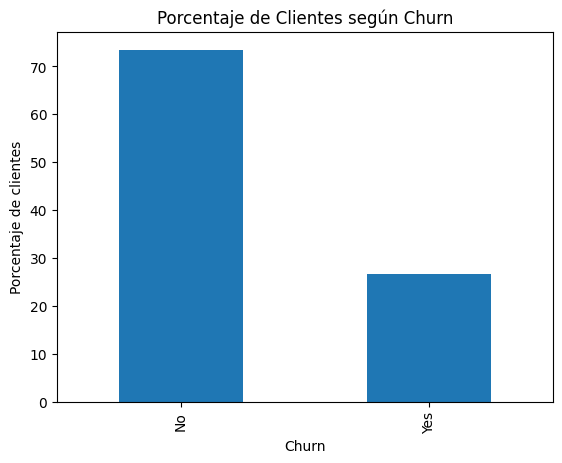

In [40]:
import matplotlib.pyplot as plt

churn_percent.plot(kind='bar')
plt.title('Porcentaje de Clientes según Churn')
plt.xlabel('Churn')
plt.ylabel('Porcentaje de clientes')
plt.show()


### **Recuento de evasion por variables categoricas**

####**Churn vs Contract**

In [43]:
df_telecom['contract'].value_counts(normalize=True) * 100

,proportion
contract,
Month-to-month,55.019168
Two year,24.066449
One year,20.914383


In [44]:
pd.crosstab(df_telecom['contract'], df_telecom['churn'], normalize='index') * 100

churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


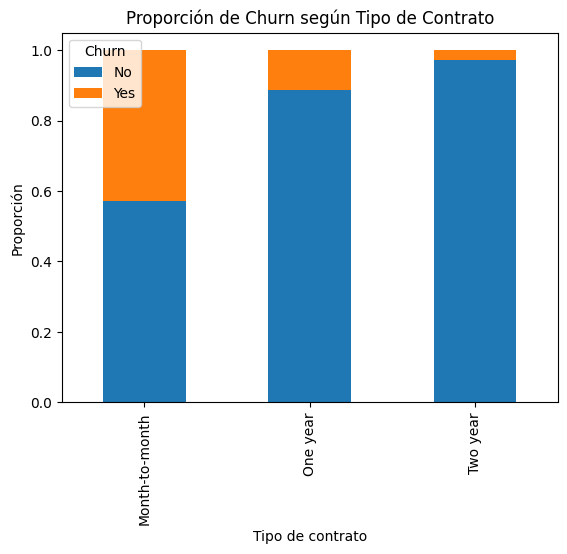

In [46]:
contract_churn = pd.crosstab(df_telecom['contract'], df_telecom['churn'], normalize='index')

contract_churn.plot(kind='bar', stacked=True)
plt.title('Proporción de Churn según Tipo de Contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Proporción')
plt.legend(title='Churn')
plt.show()


#### **Churn vs Gender**

In [47]:
df_telecom['gender'].value_counts(normalize=True) * 100

,proportion
gender,
Male,50.47565
Female,49.52435


In [48]:
pd.crosstab(df_telecom['gender'], df_telecom['churn'], normalize='index') * 100

churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


#### **Churn vs payment_method**

In [52]:
df_telecom['payment_method'].value_counts(normalize=True) * 100

,proportion
payment_method,
Electronic check,33.579441
Mailed check,22.887974
Bank transfer (automatic),21.922476
Credit card (automatic),21.610109


In [53]:
pd.crosstab(df_telecom['payment_method'], df_telecom['churn'], normalize='index') * 100

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


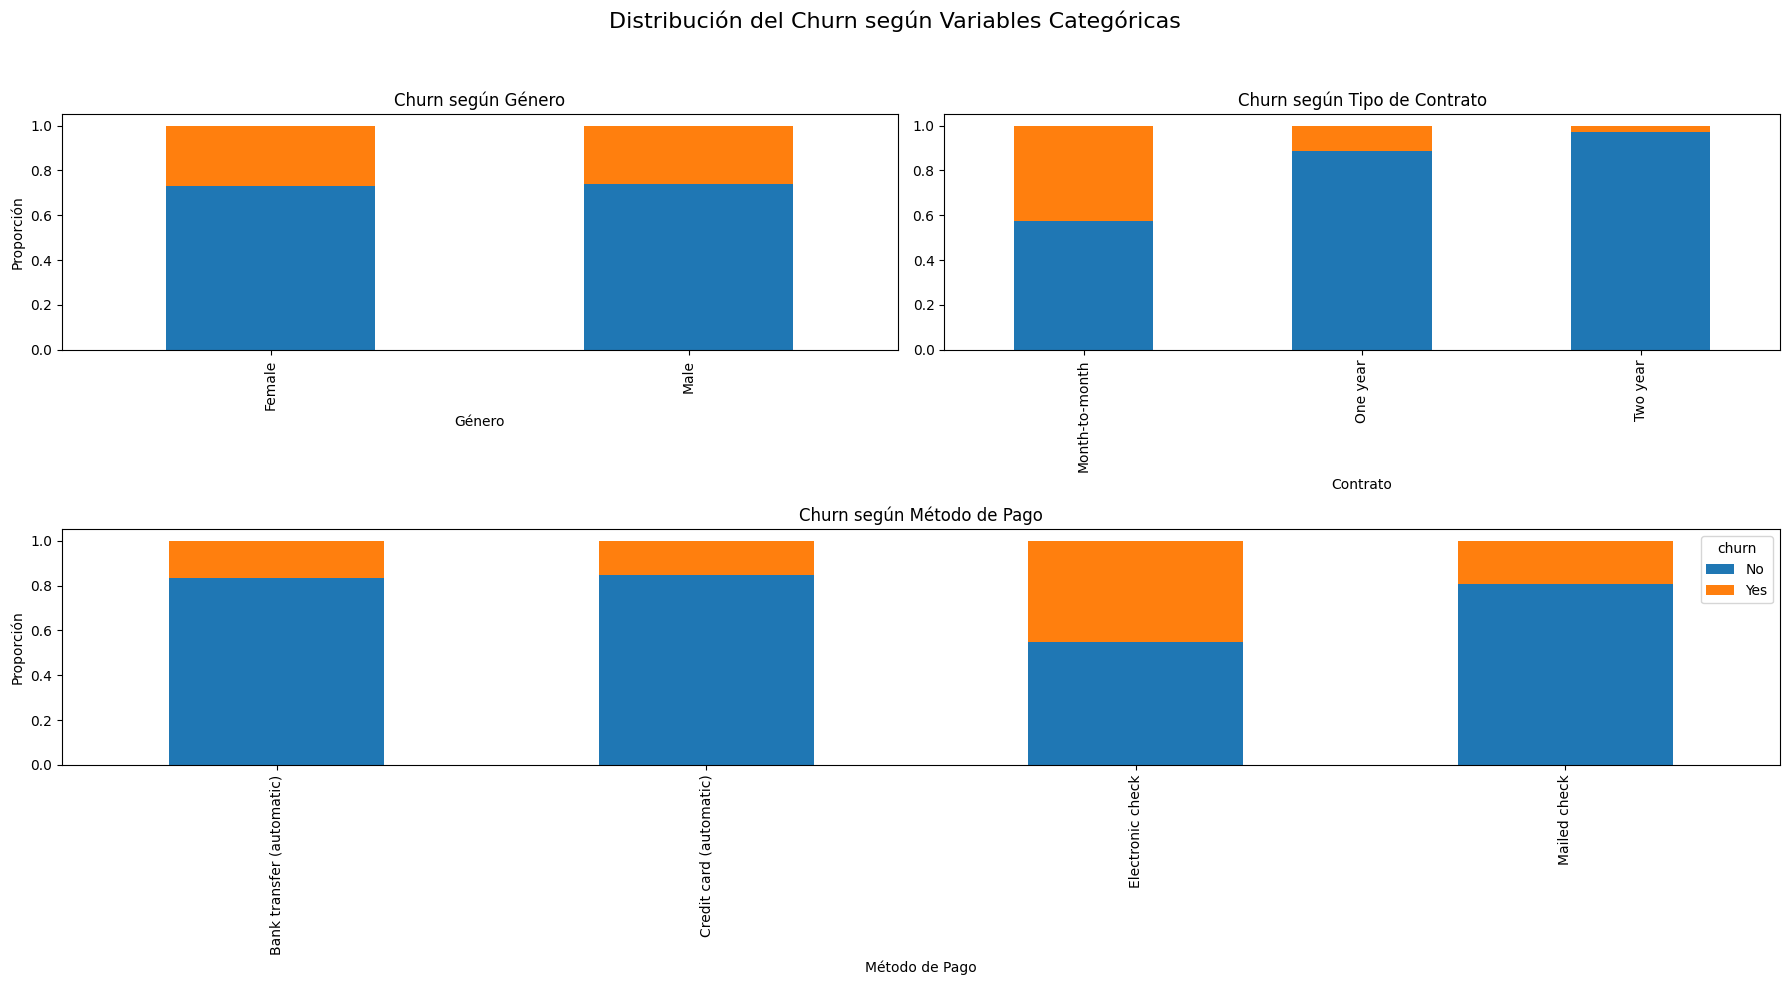

In [60]:
import matplotlib.pyplot as plt
import pandas as pd

fig = plt.figure(figsize=(18, 10))

# Definición del layout (2 filas, 2 columnas)
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)

# 1. Churn según género
pd.crosstab(df_telecom['gender'], df_telecom['churn'], normalize='index').plot(
    kind='bar', stacked=True, ax=ax1, legend=False
)
ax1.set_title('Churn según Género')
ax1.set_xlabel('Género')
ax1.set_ylabel('Proporción')

# 2. Churn según tipo de contrato
pd.crosstab(df_telecom['contract'], df_telecom['churn'], normalize='index').plot(
    kind='bar', stacked=True, ax=ax2, legend=False
)
ax2.set_title('Churn según Tipo de Contrato')
ax2.set_xlabel('Contrato')

# 3. Churn según método de pago
pd.crosstab(df_telecom['payment_method'], df_telecom['churn'], normalize='index').plot(
    kind='bar', stacked=True, ax=ax3, legend=True
)
ax3.set_title('Churn según Método de Pago')
ax3.set_xlabel('Método de Pago')
ax3.set_ylabel('Proporción')

plt.suptitle('Distribución del Churn según Variables Categóricas', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### **conteo de evasion por variables numericas**

####**Churn vs Tenure**

In [41]:
df_telecom.groupby('churn')['tenure'].describe()


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


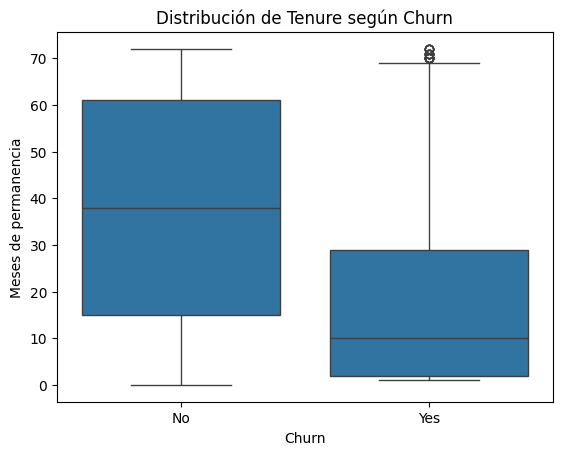

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='churn', y='tenure', data=df_telecom)
plt.title('Distribución de Tenure según Churn')
plt.xlabel('Churn')
plt.ylabel('Meses de permanencia')
plt.show()


#### **Churn vs total_charges**

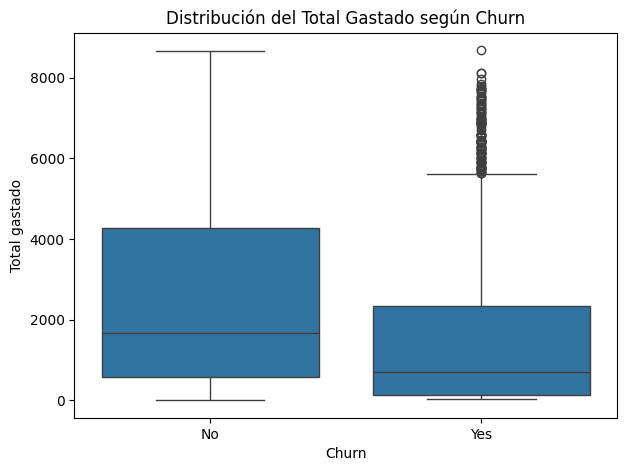

In [61]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='churn', y='total_charges', data=df_telecom)
plt.title('Distribución del Total Gastado según Churn')
plt.xlabel('Churn')
plt.ylabel('Total gastado')
plt.show()


### **conversion columna churn**

In [64]:
df_telecom['churn'] = df_telecom['churn'].map({'Yes': 1, 'No': 0})

In [65]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   churn              7043 non-null   int64  
 2   gender             7043 non-null   object 
 3   senior_citizen     7043 non-null   int64  
 4   partner            7043 non-null   int64  
 5   dependents         7043 non-null   int64  
 6   tenure             7043 non-null   int64  
 7   phone_service      7043 non-null   int64  
 8   multiple_lines     7043 non-null   int64  
 9   internet_service   7043 non-null   object 
 10  online_security    7043 non-null   int64  
 11  online_backup      7043 non-null   int64  
 12  device_protection  7043 non-null   int64  
 13  tech_support       7043 non-null   int64  
 14  streaming_tv       7043 non-null   int64  
 15  streaming_movies   7043 non-null   int64  
 16  contract           7043 non-n

# **Correlaciones**

In [71]:
vars_numericas = [
    'churn',
    'tenure',
    'monthly_charges',
    'total_charges',
    'senior_citizen',
    'partner',
    'dependents',
    'phone_service',
    'multiple_lines',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'paperless_billing'
]

df_corr = df_telecom[vars_numericas]


In [72]:
corr_matrix = df_corr.corr()

corr_matrix['churn'].sort_values(ascending=False)


,churn
churn,1.000000
monthly_charges,0.193356
paperless_billing,0.191825
senior_citizen,0.150889
streaming_tv,0.063228
streaming_movies,0.061382
multiple_lines,0.040102
phone_service,0.011942
partner,-0.150448
dependents,-0.164221


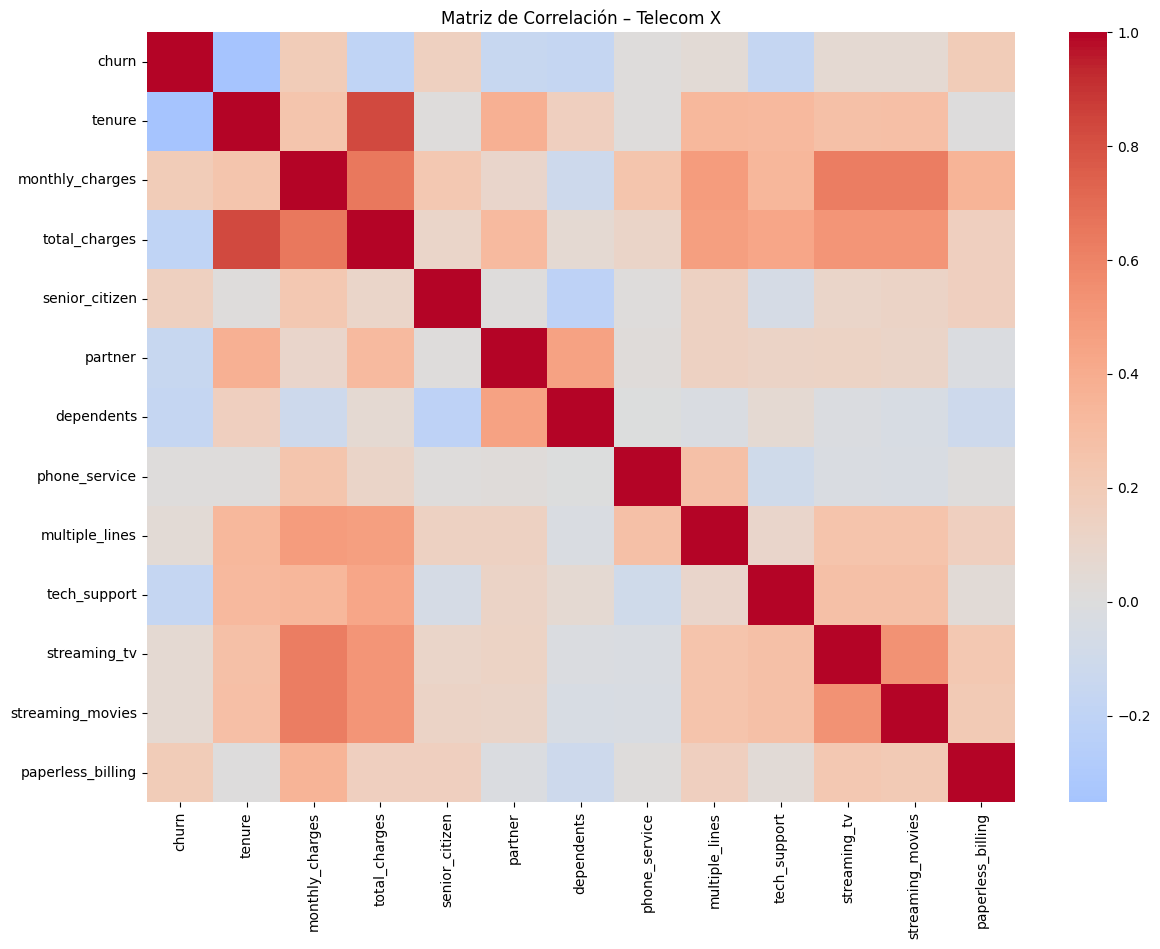

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title('Matriz de Correlación – Telecom X')
plt.show()


## **Análisis de Correlación**

Con el objetivo de identificar las variables con mayor relación con la cancelación del servicio, se realizó un análisis de correlación entre las principales variables numéricas del conjunto de datos y la variable objetivo churn. Este tipo de análisis permite evaluar el grado de asociación entre las variables y detectar posibles factores que influyen en la decisión de los clientes de abandonar el servicio.

Los resultados evidencian que variables como el tiempo de permanencia del cliente en la compañía (tenure) y la cantidad de servicios contratados presentan una correlación negativa con el churn. Esto significa que, a medida que aumenta la antigüedad del cliente o el número de servicios que utiliza, disminuye la probabilidad de cancelación. En términos de negocio, este comportamiento sugiere que los clientes con mayor nivel de vinculación con la empresa tienden a mostrar una mayor estabilidad y fidelidad hacia el servicio.

En contraste, algunas variables relacionadas con los costos del servicio, como los cargos mensuales y la cuenta diaria, muestran una correlación positiva con la evasión. Este patrón indica que los clientes que enfrentan costos más elevados presentan una mayor tendencia a cancelar el servicio. Por lo tanto, los precios y la percepción del valor recibido por el servicio podrían ser factores relevantes en la decisión de permanencia del cliente.

En conjunto, el análisis de correlación proporciona una visión inicial de las relaciones existentes entre las variables del conjunto de datos y la evasión de clientes. Estos hallazgos resultan especialmente útiles como base para el desarrollo de modelos predictivos de churn, así como para el diseño de estrategias de retención orientadas a fortalecer la relación con los clientes y reducir los factores asociados a la cancelación del servicio.


# **Conclusiones e Insights**

### **Principales Hallazgos del Análisis**

A partir del análisis exploratorio de los datos se identificaron varios patrones relevantes que permiten comprender mejor el comportamiento de los clientes y los factores asociados a la cancelación del servicio. Estos hallazgos ofrecen información valiosa para orientar futuras estrategias de análisis, así como para el desarrollo de modelos predictivos enfocados en la reducción de la evasión de clientes.

En primer lugar, se evidencia que **la tasa de evasión es considerablemente alta**, lo que confirma que la cancelación del servicio representa un **problema crítico para la empresa**. Esta situación puede afectar directamente los ingresos y la estabilidad del negocio, por lo que resulta fundamental identificar las causas que influyen en este comportamiento.

Asimismo, el análisis muestra que **los clientes con menor tiempo de permanencia en la compañía presentan una mayor probabilidad de cancelar el servicio**. Esto sugiere que las primeras etapas de la relación entre el cliente y la empresa son determinantes para su fidelización, por lo que implementar estrategias de acompañamiento y retención durante los primeros meses podría contribuir a reducir la tasa de churn.

Otro hallazgo importante está relacionado con **el tipo de contrato**. Los datos indican que **los clientes con contratos mensuales presentan niveles más altos de evasión**, mientras que aquellos con contratos de mayor duración tienden a mantenerse por más tiempo en la empresa. Este comportamiento sugiere que los compromisos contractuales más largos generan una mayor estabilidad en la relación con el cliente.

Adicionalmente, se observa que **existe una relación entre el gasto total acumulado y la probabilidad de cancelación**. En general, los clientes que presentan **menores niveles de gasto total** tienden a mostrar una mayor tendencia a abandonar el servicio, lo que podría estar relacionado con un menor nivel de vinculación o uso de los servicios ofrecidos por la compañía.

Finalmente, el análisis de diversas **variables categóricas** permitió identificar **ciertos perfiles de clientes con mayor riesgo de evasión**. Estos patrones pueden resultar especialmente útiles para segmentar a los usuarios y diseñar estrategias de retención más específicas y efectivas.

En conjunto, estos hallazgos constituyen una **base sólida para el desarrollo de modelos predictivos de churn**, así como para la implementación de estrategias orientadas a mejorar la fidelización de los clientes y reducir la tasa de cancelación en la empresa.


### **Recomendaciones Estratégicas**

Con base en los resultados obtenidos durante el análisis exploratorio de los datos, es posible plantear una serie de **acciones estratégicas orientadas a reducir la evasión de clientes y fortalecer la fidelización**. Estas recomendaciones buscan abordar los principales factores identificados que influyen en la cancelación del servicio y, al mismo tiempo, mejorar la relación entre la empresa y sus usuarios.

En primer lugar, se recomienda **implementar programas de retención temprana dirigidos a clientes nuevos**. Dado que el análisis evidenció que los usuarios con menor tiempo de permanencia presentan una mayor probabilidad de cancelar el servicio, resulta fundamental establecer estrategias de acompañamiento durante las primeras etapas del ciclo de vida del cliente. Estas iniciativas pueden incluir seguimiento personalizado, asistencia técnica prioritaria o programas de bienvenida que faciliten la adaptación al servicio.

Asimismo, sería conveniente **incentivar la migración hacia contratos de mayor duración**, como los planes anuales o bianuales. Esto podría lograrse mediante **descuentos, beneficios adicionales o promociones exclusivas**, con el objetivo de motivar a los clientes a asumir compromisos contractuales más largos, los cuales han demostrado estar asociados con menores tasas de evasión.

Otra acción relevante consiste en **fortalecer la experiencia del cliente durante los primeros meses de servicio**. Mejorar aspectos como la atención al cliente, la claridad en la facturación, la calidad del soporte técnico y la facilidad de uso de los servicios puede contribuir significativamente a generar una percepción positiva en los usuarios y aumentar su nivel de satisfacción.

Adicionalmente, se recomienda **identificar y segmentar perfiles de clientes con mayor riesgo de evasión** a partir de las variables analizadas. Esta segmentación permitiría desarrollar **estrategias preventivas personalizadas**, como ofertas especiales, comunicación directa o mejoras específicas en el servicio, con el fin de reducir la probabilidad de cancelación en estos grupos.

Finalmente, los resultados obtenidos en este análisis pueden utilizarse como **base para el desarrollo de modelos de Machine Learning orientados a la predicción del churn**. La implementación de estos modelos permitiría anticipar qué clientes tienen mayor probabilidad de abandonar el servicio, facilitando la toma de decisiones proactivas y el diseño de estrategias de retención más efectivas basadas en datos.

En conjunto, estas acciones estratégicas pueden contribuir significativamente a **reducir la tasa de evasión, mejorar la fidelización de los clientes y fortalecer la sostenibilidad del negocio a largo plazo**.
